In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv("silver_prices_data.csv")

In [4]:
data['Date'] = pd.to_datetime(data['Date'])

In [5]:
data.set_index('Date', inplace=True)

c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


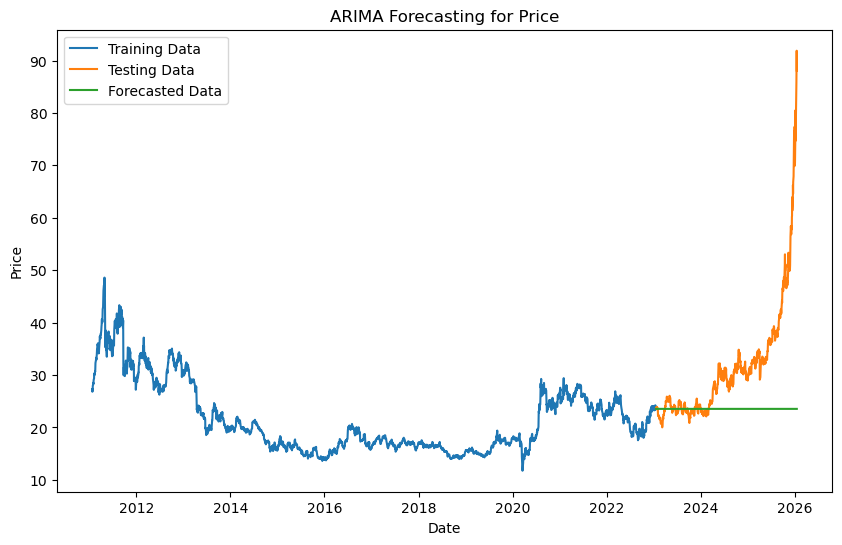

Root Mean Squared Error (RMSE): 13.662153535093134


In [10]:
def arima_model(data, target_variable, order):
    train_size = int(len(data) * 0.8)
    train_data, test_data = data[:train_size], data[train_size:]

    model = ARIMA(train_data[target_variable], order=order)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test_data))

    rmse = np.sqrt(mean_squared_error(test_data[target_variable], forecast))

    plt.figure(figsize=(10, 6))
    plt.plot(train_data.index, train_data[target_variable], label='Training Data')
    plt.plot(test_data.index, test_data[target_variable], label='Testing Data')
    plt.plot(test_data.index, forecast, label='Forecasted Data')
    plt.xlabel('Date')
    plt.ylabel(target_variable)
    plt.title('ARIMA Forecasting for ' + target_variable)
    plt.legend()
    plt.show()

    print("Root Mean Squared Error (RMSE):", rmse)
arima_model(data, 'Price', order=(5,1,0))